In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('dark')
%matplotlib inline

from itertools import combinations
from scipy.sparse import csr_matrix
from implicit.bpr import BayesianPersonalizedRanking
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, ndcg_score

### Download Datasets ###

In [2]:
df_movies = pd.read_csv('movies.csv')
df_movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
df_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  3883 non-null   int64 
 1   title    3883 non-null   object
 2   genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB


In [3]:
df_ratings = pd.read_csv('ratings.csv')
df_ratings.head()

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [5]:
df_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   userId     1000209 non-null  int64
 1   movieId    1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [4]:
df_users = pd.read_csv('users.csv')
df_users.head()

,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [7]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   userId      6040 non-null   int64 
 1   gender      6040 non-null   object
 2   age         6040 non-null   int64 
 3   occupation  6040 non-null   int64 
 4   zip         6040 non-null   object
dtypes: int64(3), object(2)
memory usage: 236.1+ KB


### Data Exploration ###

In [65]:
df_ratings.describe()

,userId,movieId,rating,timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


In [79]:
num_ratings = len(df_ratings)
num_movies = df_ratings["movieId"].nunique()
num_users = df_ratings["userId"].nunique()

print(f"Average number of ratings per user: {round(num_ratings/num_users, 2)}")


Average number of ratings per user: 165.6


In [78]:
# merge datasets of movies and ratings
movies_rating = pd.merge(df_ratings, df_movies, on='movieId')
movies_rating.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1193,5,978300760,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:
# check the movie average rating values in ascending order
movies_rating.groupby('title')['rating'].mean().sort_values(ascending=False).head()

title
Ulysses (Ulisse) (1954)     5.0
Lured (1947)                5.0
Follow the Bitch (1998)     5.0
Bittersweet Motel (2000)    5.0
Song of Freedom (1936)      5.0
Name: rating, dtype: float64

In [83]:
# check the total number of ratings for each movie Id in ascending order
movies_rating.groupby('title')['rating'].count().sort_values(ascending=False).head()

title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Name: rating, dtype: int64

In [ ]:
# create a dataset that conclues total numbers of rating counts and average of ratings per movie Id
rating_mean = pd.DataFrame(movies_rating.groupby('title')['rating'].mean())
rating_mean['rating counts'] = pd.DataFrame(movies_rating.groupby('title')['rating'].count())
rating_mean.head()

,rating,rating counts
title,,
"$1,000,000 Duck (1971)",3.027027,37
'Night Mother (1986),3.371429,70
'Til There Was You (1997),2.692308,52
"'burbs, The (1989)",2.910891,303
...And Justice for All (1979),3.713568,199


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

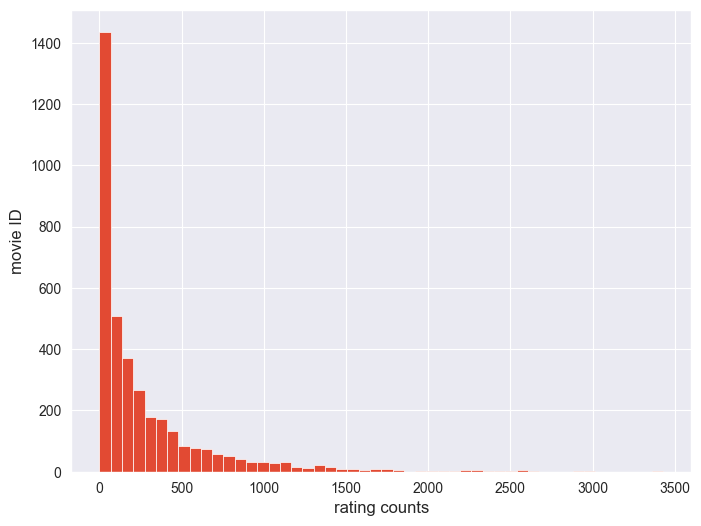

In [ ]:
# plot total rating counts per movie ID
plt.figure(figsize=(8,6))
plt.rcParams['patch.force_edgecolor'] = True
plt.xlabel('rating counts')
plt.ylabel('movie ID')
rating_mean['rating counts'].hist(bins=50)
plt.show()

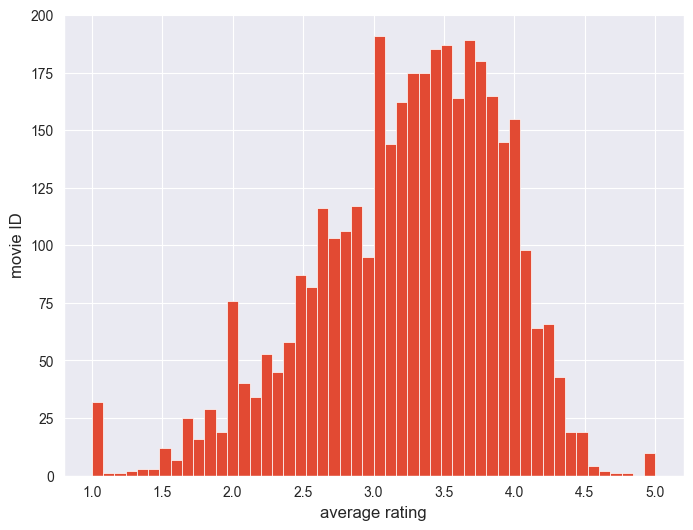

In [ ]:
# plot average rating per movie ID
plt.figure(figsize=(8,6))
plt.rcParams['patch.force_edgecolor'] = True
plt.xlabel('average rating')
plt.ylabel('movie ID')
rating_mean['rating'].hist(bins=50)
plt.show()

<Figure size 800x600 with 0 Axes>

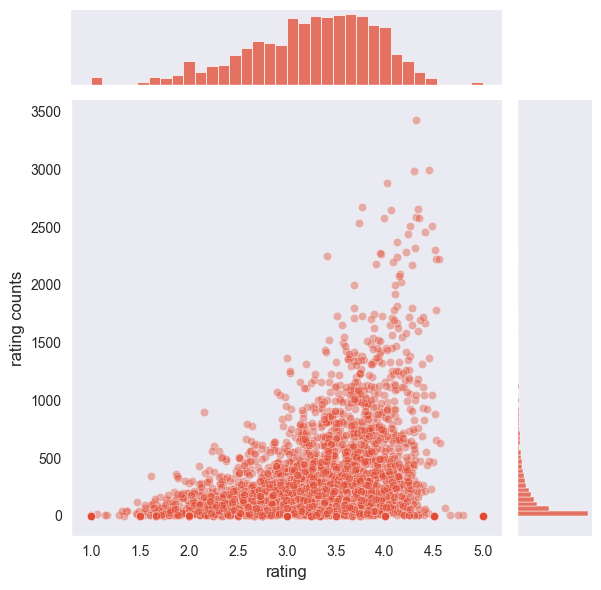

In [109]:
# explore the relation average of rating VS. numbers of rating
plt.figure(figsize=(8,6))
plt.rcParams['patch.force_edgecolor'] = True
sns.jointplot(x='rating', y='rating counts', data=rating_mean, alpha=0.4)
plt.show()

In [ ]:
# relation between users and movies
movie_rating_user = movies_rating.pivot_table(index='userId', columns='title', values='rating')
movie_rating_user.head()

title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjï¿½rlighetens kjï¿½tere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [115]:
# Convert the NaN values to integer values
movie_rating_user.fillna(0, inplace=True)
movie_rating_user.head()

title,"$1,000,000 Duck (1971)",'Night Mother (1986),'Til There Was You (1997),"'burbs, The (1989)",...And Justice for All (1979),1-900 (1994),10 Things I Hate About You (1999),101 Dalmatians (1961),101 Dalmatians (1996),12 Angry Men (1957),...,"Young Poisoner's Handbook, The (1995)",Young Sherlock Holmes (1985),Young and Innocent (1937),Your Friends and Neighbors (1998),Zachariah (1971),"Zed & Two Noughts, A (1985)",Zero Effect (1998),Zero Kelvin (Kjï¿½rlighetens kjï¿½tere) (1995),Zeus and Roxanne (1997),eXistenZ (1999)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [116]:
# check a random movie's rating from all users
jurassic_park_rating = movie_rating_user['Jurassic Park (1993)']
jurassic_park_rating.head()

userId
1    0.0
2    5.0
3    4.0
4    4.0
5    0.0
Name: Jurassic Park (1993), dtype: float64

In [ ]:
# Explore the original missing data - movie Ids that each user has never given any ratings
df = df_ratings.pivot(index="movieId", columns="userId", values="rating")
df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
movieId,,,,,,,,,,,,,,,,,,,,,
1,5.0,NaN,NaN,NaN,NaN,4.0,NaN,4.0,5.0,5.0,...,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,3.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,2.0,2.0,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [60]:
# Convert the NaN values to integer values
df.fillna(0, inplace=True)
df.head

<bound method NDFrame.head of userId   1     2     3     4     5     6     7     8     9     10    ...  \
movieId                                                              ...   
1         5.0   0.0   0.0   0.0   0.0   4.0   0.0   4.0   5.0   5.0  ...   
2         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   5.0  ...   
3         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
4         0.0   0.0   0.0   0.0   0.0   0.0   0.0   3.0   0.0   0.0  ...   
5         0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
...       ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   
3948      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   3.0   4.0  ...   
3949      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
3950      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
3951      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   
3952      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   

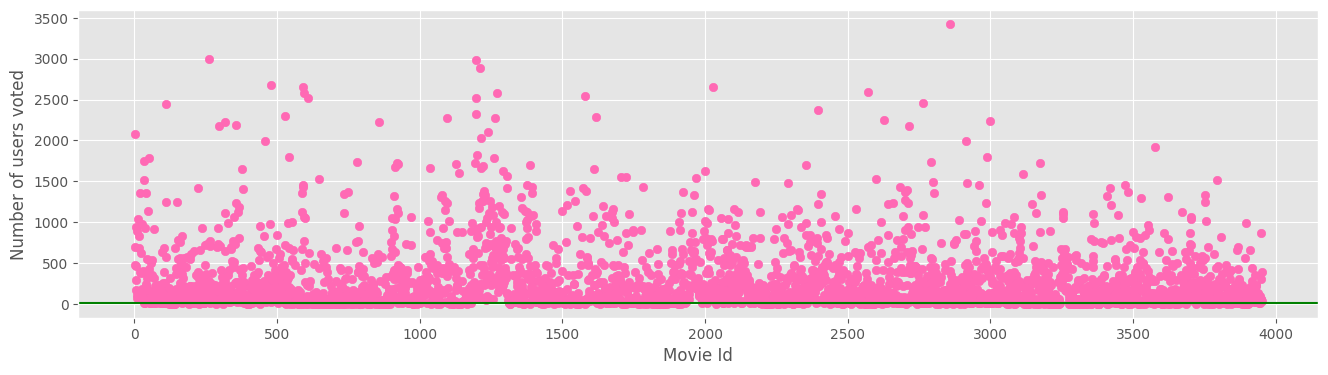

In [61]:
# Removing noise from dataset
num_user_voted = df_ratings.groupby("movieId")['rating'].agg('count')
num_movies_voted = df_ratings.groupby("userId")['rating'].agg('count')

# plot the user Ids that voted at least 5 movie Ids
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16, 4))
plt.scatter(num_user_voted.index, num_user_voted, color="hotpink")
plt.axhline(y=5, color='green')
plt.xlabel("Movie Id")
plt.ylabel("Number of users voted")
plt.show()

In [62]:
df = df.loc[num_user_voted[num_user_voted > 5].index, :]
df

userId,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
movieId,,,,,,,,,,,,,,,,,,,,,
1,5.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,5.0,5.0,...,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3949,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3950,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


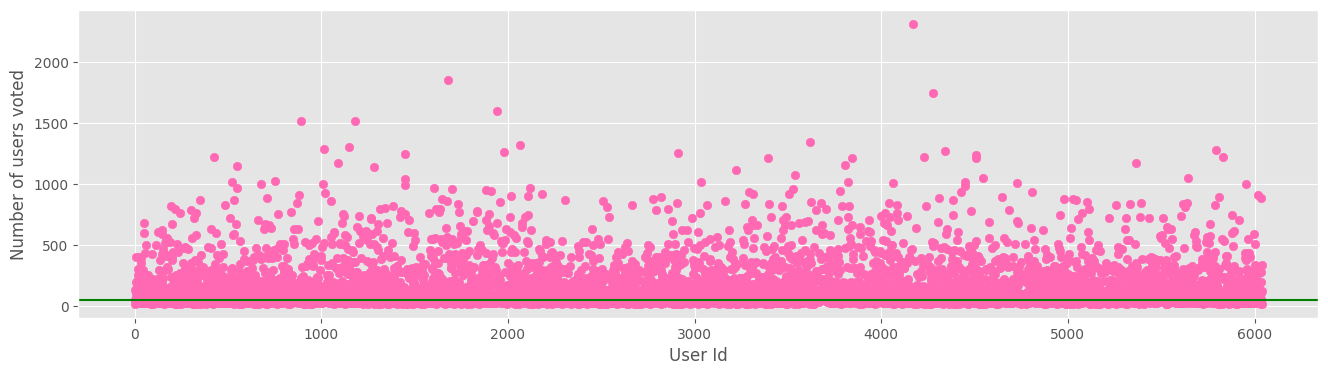

In [63]:
# plot the movie Ids that have been voted by at least 50 user Ids
plt.style.use("ggplot")
fig,axes = plt.subplots(1,1, figsize=(16, 4))
plt.scatter(num_movies_voted.index, num_movies_voted, color="hotpink")
plt.axhline(y=50, color='green')
plt.xlabel("User Id")
plt.ylabel("Number of users voted")
plt.show()

In [64]:
df = df.loc[: , num_movies_voted[num_movies_voted>50].index]
df.shape

(3377, 4247)

In [10]:
user_ratings = df_ratings['userId'].value_counts()
user_ratings

userId
4169    2314
1680    1850
4277    1743
1941    1595
1181    1521
        ... 
5725      20
3407      20
1664      20
4419      20
3021      20
Name: count, Length: 6040, dtype: int64

In [11]:
user_ratings.describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: count, dtype: float64

### Data Processing ###

In [5]:
# function to build pairwise preference
def pairwise_preferences(df_ratings, min_rating_diff=3, min_movies_per_user=70):
    # filter users that gave ratings for less than 5 movies
    user_rating_counts = df_ratings['userId'].value_counts()
    active_users = user_rating_counts[user_rating_counts >= min_movies_per_user].index
    df_filtered = df_ratings[df_ratings['userId'].isin(active_users)]

    # Pairwise preferences
    pairwise_data = []

    # Loop through over every user
    for user_id, group in df_ratings.groupby("userId"):
        rated_items = group[["movieId", "rating"]].values
        for (movie_a, rating_a), (movie_b, rating_b) in combinations(rated_items, 2):
            if rating_a == rating_b:
                continue
            if abs(rating_a - rating_b) < min_rating_diff:
                continue

            if rating_a > rating_b:
                preferred, less_preferred = movie_a, movie_b
                comparison = f"{rating_a} > {rating_b}"
            else:
                preferred, less_preferred = movie_b, movie_a
                pairwise_data.append((user_id, movie_b, movie_a))

            pairwise_data.append((user_id, comparison, preferred, less_preferred))

    # Structure DataFrame for pairwise preference
    df_pairwise = pd.DataFrame(pairwise_data, columns=["User ID", "Rating Comparison", "Preferred Movie ID", "Less Preferred Movie ID"])
    #df_pairwise = pd.DataFrame(pairwise_data, columns=["userId", "Preferred Movie Title ", "Less preferred Movie Title"])
    #df_pairwise = pd.DataFrame(pairwise_data, columns=["userId", "preferred", "less_preferred"])
    return df_pairwise

    """
    # Merge preferred movie titles
    df_pairwise = df_pairwise.merge(df_movies[['movieId', 'title']], left_on='preferred', right_on='movieId')
    df_pairwise = df_pairwise.rename(columns={'title': 'Preferred Movie Title'}).drop('movieId', axis=1)

    # Merge less preferred movie titles
    df_pairwise = df_pairwise.merge(df_movies[['movieId', 'title']], left_on='less_preferred', right_on='movieId')
    df_pairwise = df_pairwise.rename(columns={'title': 'Less Preferred Movie Title'}).drop('movieId', axis=1)

    # 只显示结果列
    print(df_pairwise[['userId', 'Preferred Movie Title', 'Less Preferred Movie Title']].head())
    """

In [6]:
# function to merge movie titles
def merge_movies_comparison(df_pairwise, df_movies):
    """"
    Add movie title and absolute compairsion columns to pairwise preference table

    parameter:
        df_pairwise: DataFrame contains user ID, preferred movie ID, and rating comparison
        df_movies: Movie information table containing movie ID and title

    return:
        Add new DataFrames for movie titles and movie preference comparison
    """""
    
    # merge preferred movie names
    df_pairwise = df_pairwise.merge(
        df_movies[["movieId", "title"]],
        left_on="Preferred Movie ID",
        right_on="movieId",
        how="left"
    )
    df_pairwise = df_pairwise.rename(columns={"title": "Preferred Movie Title"}).drop(columns="movieId")

    # merge less preferred movie names
    df_pairwise = df_pairwise.merge(
        df_movies[["movieId", "title"]],
        left_on="Less Preferred Movie ID",
        right_on="movieId",
        how="left"
    )
    df_pairwise = df_pairwise.rename(columns={"title": "Less Preferred Movie Title"}).drop(columns="movieId")

    df_pairwise["Movie Preference Comparison"] = df_pairwise["Preferred Movie Title"] + " > " + df_pairwise["Less Preferred Movie Title"]
    
    return df_pairwise

In [7]:
# print pairwise preference dataset
df_pairwise = pairwise_preferences(df_ratings, min_rating_diff=3, min_movies_per_user=70)
df_pairwise.head()

,User ID,Rating Comparison,Preferred Movie ID,Less Preferred Movie ID
0,2,5 > 2,1357,1213.0
1,2,5 > 2,1357,434.0
2,2,5 > 2,1357,3107.0
3,2,5 > 2,1357,902.0
4,2,5 > 2,1357,3256.0


In [11]:
# save pairwise preference dataset to csv
df_pairwise.to_csv('pairwise_preference.csv', index=False)

In [123]:
# print pairwise preference with title dataset
pairwise_title = merge_movies_comparison(df_pairwise, df_movies)
pairwise_title.head()

,User ID,Rating Comparison,Preferred Movie ID,Less Preferred Movie ID,Preferred Movie Title,Less Preferred Movie Title,Movie Preference Comparison
0,1,5 > 3,1193,661.0,One Flew Over the Cuckoo's Nest (1975),James and the Giant Peach (1996),One Flew Over the Cuckoo's Nest (1975) > James...
1,1,5 > 3,1193,914.0,One Flew Over the Cuckoo's Nest (1975),My Fair Lady (1964),One Flew Over the Cuckoo's Nest (1975) > My Fa...
2,1,5 > 3,1193,1197.0,One Flew Over the Cuckoo's Nest (1975),"Princess Bride, The (1987)",One Flew Over the Cuckoo's Nest (1975) > Princ...
3,1,5 > 3,1193,2687.0,One Flew Over the Cuckoo's Nest (1975),Tarzan (1999),One Flew Over the Cuckoo's Nest (1975) > Tarza...
4,1,5 > 3,1193,2321.0,One Flew Over the Cuckoo's Nest (1975),Pleasantville (1998),One Flew Over the Cuckoo's Nest (1975) > Pleas...


In [124]:
# save pairwise preference with titles dataset to csv
pairwise_title.to_csv('pairwise_title.csv', index=False)

In [37]:
df_pairwise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26380995 entries, 0 to 26380994
Data columns (total 4 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   User ID                  int64  
 1   Rating Comparison        object 
 2   Preferred Movie ID       int64  
 3   Less Preferred Movie ID  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 805.1+ MB


In [126]:
pairwise_title.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84267582 entries, 0 to 84267581
Data columns (total 7 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   User ID                      int64  
 1   Rating Comparison            object 
 2   Preferred Movie ID           int64  
 3   Less Preferred Movie ID      float64
 4   Preferred Movie Title        object 
 5   Less Preferred Movie Title   object 
 6   Movie Preference Comparison  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 4.4+ GB


# Bayesian Personalize Ranking (BPR) #

In [8]:
 # Function to convert pairwise preference data to CSR matric for BPR model
def to_csr_matrix(df_pairwise):
    """
    Convert pairwise preference DataFrame to CSR matrix for BPR model.
    Input: df_pairwise with columns [User ID, Preferred Movie ID]
    Output: user-item sparse interaction matrix
    """

    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()

    user_ids = user_encoder.fit_transform(df_pairwise["User ID"])
    item_ids = item_encoder.fit_transform(df_pairwise["Preferred Movie ID"])

    data = np.ones(len(df_pairwise))
    user_item_matrix = csr_matrix((data, (user_ids, item_ids)))
    
    return user_item_matrix, user_encoder, item_encoder
    

In [9]:
# Train BPR Matrix Factorization model using implicit library
def train_bpr_model(df_pairwise, factors=128, regularization=0.05, learning_rate=0.01, iterations=100, show_progress=True):
    # call to_csr_matrix function to convert training data to sparse matrix
    user_item_matrix, user_encoder, item_encoder = to_csr_matrix(df_pairwise)

    # Initialized and train the model
    model = BayesianPersonalizedRanking(
        factors=factors,
        regularization=regularization,
        learning_rate = learning_rate,
        iterations=iterations,
        use_gpu=False
    )
    model.fit(user_item_matrix, show_progress=show_progress)

    return model, user_encoder, item_encoder, user_item_matrix


In [ ]:
model, user_encoder, item_encoder, user_item_matrix = train_bpr_model(df_pairwise, factors=128, regularization=0.05, learning_rate=0.01, iterations=100)
print(model, user_encoder, item_encoder, user_item_matrix)

  0%|          | 0/100 [00:00<?, ?it/s]

<implicit.cpu.bpr.BayesianPersonalizedRanking object at 0x16b672f00> LabelEncoder() LabelEncoder() <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 687748 stored elements and shape (5772, 3654)>
  Coords	Values
  (0, 20)	19.0
  (0, 92)	13.0
  (0, 106)	13.0
  (0, 155)	2.0
  (0, 256)	2.0
  (0, 305)	13.0
  (0, 335)	2.0
  (0, 342)	13.0
  (0, 354)	2.0
  (0, 366)	13.0
  (0, 415)	30.0
  (0, 438)	2.0
  (0, 461)	13.0
  (0, 496)	13.0
  (0, 568)	2.0
  (0, 569)	13.0
  (0, 572)	13.0
  (0, 617)	2.0
  (0, 690)	2.0
  (0, 821)	28.0
  (0, 839)	13.0
  (0, 900)	2.0
  (0, 996)	10.0
  (0, 1002)	2.0
  (0, 1025)	13.0
  :	:
  (5771, 2920)	65.0
  (5771, 2936)	27.0
  (5771, 2959)	65.0
  (5771, 2993)	27.0
  (5771, 3018)	65.0
  (5771, 3060)	65.0
  (5771, 3082)	27.0
  (5771, 3084)	9.0
  (5771, 3085)	27.0
  (5771, 3109)	23.0
  (5771, 3144)	66.0
  (5771, 3189)	27.0
  (5771, 3222)	27.0
  (5771, 3223)	27.0
  (5771, 3239)	65.0
  (5771, 3242)	143.0
  (5771, 3260)	27.0
  (5771, 3264)	27.0
  (5771, 3269)	44.0


In [11]:
# Simulate individual recommendation system
def recommendation_userCentric(model, user_id, user_encoder, item_encoder, df_movies, df_ratings, user_item_matrix, N=10):
    """
    Recommend top-N movies for a given user
    """
    # Check if the user in the training dataset
    if user_id not in user_encoder.classes_:
        print(f"❌ User {user_id} does not exist in the training dataset, please re-enter the user_id (between: {user_encoder.classes_[0]} ~ {user_encoder.classes_[-1]})")
        return pd.DataFrame()

    # Convert raw user_id to model internal id
    internal_user_id = user_encoder.transform([user_id])[0]

    # Get moviesIds that user has rated
    watched_movie_ids = df_ratings[df_ratings["userId"] == user_id]["movieId"].unique()
    watched_internal_ids = item_encoder.transform([m for m in watched_movie_ids if m in item_encoder.classes_])
    
    # Recommend non-watched movies to user
    recommended = model.recommend(
        userid=internal_user_id,
        user_items=user_item_matrix[internal_user_id],         # implicit recommend for all items
        N=N,
        filter_items=watched_internal_ids,  # filter movies that user has watched
        #retrurn_scores=True
    )
    """
    if isinstance(recommended, tuple) and len(recommended) == 2:
        recommended_ids = recommended[0]
    else:
        recommended_ids = recommended
    #scores = [None] * len(recommended_ids)
    """
    # Extract movieId, scores from the sparse matrix
    recommended_ids = recommended[0]
    scores = recommended[1]

    # Decode item ids back to original movieId
    movie_ids = item_encoder.inverse_transform(recommended_ids)

    # Create a dataframe with results
    df = pd.DataFrame({
        "userId": user_id,
        "movieId": movie_ids,
        "Score": scores
    }).merge(df_movies, on="movieId", how="left")

    return df[["userId", "movieId", "title", "Score"]]

In [22]:
user_input = int(input("Please input user ID: "))

recommendations = recommendation_userCentric(
        model,
        user_id=user_input,
        user_encoder=user_encoder,
        item_encoder=item_encoder,
        df_movies=df_movies,
        df_ratings=df_ratings,
        user_item_matrix=user_item_matrix,
        N=10
    )

print(f"Recommend movies to user ID {user_input}:")
recommendations

Recommend movies to user ID 5:


,userId,movieId,title,Score
0,5,3160,Magnolia (1999),1.733609
1,5,3949,Requiem for a Dream (2000),1.725755
2,5,1354,Breaking the Waves (1996),1.655101
3,5,3509,Black and White (1999),1.646130
4,5,3481,High Fidelity (2000),1.565939
5,5,2769,"Yards, The (1999)",1.546988
6,5,3162,Simpatico (1999),1.534009
7,5,1119,Drunks (1997),1.511614
8,5,3747,Jesus' Son (1999),1.506543
9,5,3951,Two Family House (2000),1.498403


# From Individual Scores to Group Recommendations #
### Experiment with different aggregation strategies to create a group-level preference score ###

In [13]:
# Function to define random user group
def randomUserGroup(user_encoder, group_size):
    """
    Randomly select a group of users from the available user IDs
    """
    available_user_ids = user_encoder.classes_
    return np.random.choice(available_user_ids, size=group_size, replace=False)    


In [ ]:
# Function to define user group based on similarities of user characteristicc


In [14]:
# function to apply group recommendation aggregation 
def groupRecommendation(model, user_group, user_encoder, item_encoder, df_movies, df_ratings,user_item_matrix, N=10, strategy="average"):
    group_scores = pd.DataFrame()

    # Collect individual scores for each user
    for user_id in user_group:
        user_scores = recommendation_userCentric(
            model, user_id, user_encoder, item_encoder, df_movies, df_ratings, user_item_matrix, N=N*3
        )
        user_scores["userId"] = user_id
        group_scores = pd.concat([group_scores, user_scores])

    # Aggregate scores
    if strategy == 'average':
        aggregated_scores = group_scores.groupby(["movieId", "title"]).agg({"Score": "mean"}).reset_index()
    elif strategy == 'least_minsery':
        aggregated_scores = group_scores.groupby(["movieId", "title"]).agg({"Score": "min"}).reset_index()
    elif strategy == 'fairness':
        aggregated_scores = group_scores.groupby(["movieId", "title"]).agg({"Score": lambda x: np.mean(x) - np.std(x)}).reset_index()
    
    return aggregated_scores.sort_values(by="Score", ascending=False).head(N)



### Simulate Randam Group Recommendation - Average Strategy based ###

In [15]:
user_group = randomUserGroup(user_encoder, 3)

group_recommended = groupRecommendation(
    model=model,
    user_group=user_group,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    df_movies=df_movies,
    df_ratings=df_ratings,
    user_item_matrix=user_item_matrix,
    N=10,
    strategy='average'
)

print(f"Recommended movie list to random user group {user_group} - Average Strategy based prediction")
group_recommended

Recommended movie list to random user group [ 681 3639 4094] - Average Strategy based prediction


,movieId,title,Score
24,1029,Dumbo (1941),1.857988
23,1028,Mary Poppins (1964),1.768431
43,2080,Lady and the Tramp (1955),1.752357
46,2087,Peter Pan (1953),1.733503
22,1024,"Three Caballeros, The (1945)",1.674570
25,1032,Alice in Wonderland (1951),1.659874
42,2078,"Jungle Book, The (1967)",1.652577
31,1282,Fantasia (1940),1.642923
15,596,Pinocchio (1940),1.558209
20,919,"Wizard of Oz, The (1939)",1.555892


### Simulate Randam Group Recommendation - Least Misery Strategy based ###

In [16]:
user_group = randomUserGroup(user_encoder, 3)

group_recommended = groupRecommendation(
    model=model,
    user_group=user_group,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    df_movies=df_movies,
    df_ratings=df_ratings,
    user_item_matrix=user_item_matrix,
    N=10,
    strategy='least_minsery'
)

print(f"Recommended movie list to random user group {user_group} - Least Misery Strategy based prediction")
group_recommended

Recommended movie list to random user group [1972 1394  979] - Least Misery Strategy based prediction


,movieId,title,Score
32,1250,"Bridge on the River Kwai, The (1957)",1.729371
35,1272,Patton (1970),1.500994
3,111,Taxi Driver (1976),1.473589
36,1276,Cool Hand Luke (1967),1.450017
17,593,"Silence of the Lambs, The (1991)",1.448204
31,1234,"Sting, The (1973)",1.415272
11,368,Maverick (1994),1.402046
77,3256,Patriot Games (1992),1.384989
27,1213,GoodFellas (1990),1.384745
10,349,Clear and Present Danger (1994),1.376128


### Simulate Randam Group Recommendation - Fairness-Aware Strategy based ###

In [17]:
user_group = randomUserGroup(user_encoder, 3)

group_recommended = groupRecommendation(
    model=model,
    user_group=user_group,
    user_encoder=user_encoder,
    item_encoder=item_encoder,
    df_movies=df_movies,
    df_ratings=df_ratings,
    user_item_matrix=user_item_matrix,
    N=10,
    strategy='fairness'
)

print(f"Recommended movie list to random user group {user_group} - Fairness-Aware Strategy based prediction")
group_recommended

Recommended movie list to random user group [5141 1973 2465] - Fairness-Aware Strategy based prediction


,movieId,title,Score
25,1372,Star Trek VI: The Undiscovered Country (1991),1.950257
38,1945,On the Waterfront (1954),1.855105
23,1356,Star Trek: First Contact (1996),1.854276
18,1210,Star Wars: Episode VI - Return of the Jedi (1983),1.826658
6,480,Jurassic Park (1993),1.817834
27,1374,Star Trek: The Wrath of Khan (1982),1.792818
4,329,Star Trek: Generations (1994),1.774296
12,904,Rear Window (1954),1.766044
39,1950,In the Heat of the Night (1967),1.760738
9,692,Solo (1996),1.755200


### BPR Model Evaluation ###

In [23]:
#df_ratings_sorted = df_ratings.sort_values(by='timestamp')

#train_ratings = df_ratings_sorted.groupby('userId').apply(lambda x: x.iloc[:-int(0.2 * len(x))]).reset_index(drop=True)
#test_ratings = df_ratings_sorted.groupby('userId').apply(lambda x: x.iloc[-int(0.2 * len(x)):]).reset_index(drop=True)

# Assign the rating dataset: 80% for model training and 20% for model testing/evaluation
train_ratings, test_ratings = train_test_split(df_ratings, test_size=0.2, random_state=42)

# Generate pairwise preference data from the train ratings dataset by filtering part of users and movies
df_pairwise_train = pairwise_preferences(train_ratings, min_rating_diff=3, min_movies_per_user=70)
#df_pairwise_train = pairwise_preferences(train_ratings, min_rating_diff=2, min_movies_per_user=70)

print("df_pairwise_train dataset size:", df_pairwise_train.shape)

df_pairwise_train dataset size: (16898012, 4)


In [24]:
model, user_encoder, item_encoder, user_item_matrix_train = train_bpr_model(
    df_pairwise_train,
    factors=128,
    regularization=0.05,
    learning_rate=0.01,
    iterations=100
)

  0%|          | 0/100 [00:00<?, ?it/s]

In [25]:
# function to evaluate individual recommendation model's Precision, recall and NDCG at top-N recommended movies that they have never seen
def evaluateUser_model(model, test_ratings, user_encoder, item_encoder, user_item_matrix_train, k=10):
    precision_list = []
    recall_list = []
    ndcg_list = []

    test_user_ids = test_ratings["userId"].unique()

    for user_id in test_user_ids:
        if user_id not in user_encoder.classes_:
            continue

        internal_user_id = user_encoder.transform([user_id])[0]
        # filter movies that users have watched in the train dataset
        watched_movie_ids_train = train_ratings[train_ratings["userId"] == user_id]["movieId"].unique()
        watched_internal_ids_train = item_encoder.transform([m for m in watched_movie_ids_train if m in item_encoder.classes_]).astype(np.int32)

        # Model recommend top-k movies
        user_items_csr=user_item_matrix_train[internal_user_id].tocsr()
        recommended_ids, _ = model.recommend(
            internal_user_id,
            user_items=user_items_csr,
            N=k,
            filter_items=watched_internal_ids_train,
            #return_scores=True
        )

        # Extract movieId, scores from the sparse matrix
        #recommended = recommended_ids[0]
        #scores = recommended_ids[1]

        recommended_movie_ids = item_encoder.inverse_transform(recommended_ids)

        # collect users' actual like movies (rating >= 4) that in the test dataset
        actual_liked_movies = test_ratings[
            (test_ratings["userId"] == user_id) &
            (test_ratings["rating"] >= 3)
        ]["movieId"].values

        # Compute precision and reall
        hits = np.isin(recommended_movie_ids, actual_liked_movies)
        precision = np.sum(hits) / k
        recall = np.sum(hits) / len(actual_liked_movies) if len(actual_liked_movies) > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)

        # Compute NDCG
        dcg = np.sum(hits / np.log2(np.arange(2, k + 2)))
        ideal_hits = np.ones(min(len(actual_liked_movies), k))
        idcg = np.sum(ideal_hits / np.log2(np.arange(2, len(ideal_hits) + 2)))
        ndcg = dcg / idcg if idcg > 0 else 0
        ndcg_list.append(ndcg)

    # calculate average values
    avg_precision = np.mean(precision_list) * 100
    avg_recall = np.mean(recall_list) * 100
    avg_ndcg = np.mean(ndcg_list) * 100

    print(f"Model Evaludation for individual recommendation:")
    print(f"Average Precision@{k}: {avg_precision: .4f}%")
    print(f"Average Recall@{k}: {avg_recall: .4f}%")
    print(f"Average NDCG@{k}: {avg_ndcg: .4f}%")

    return avg_precision, avg_recall, avg_ndcg

# call the evaluate function
evaluate_metrics = evaluateUser_model(
    model,
    test_ratings,
    user_encoder,
    item_encoder,
    user_item_matrix_train,
    k=10
)

Model Evaludation for individual recommendation:
Average Precision@10:  18.3236%
Average Recall@10:  8.8007%
Average NDCG@10:  21.2698%


In [41]:
# function to evaluate random user group recommendation model
def evaluate_randomGroup(model, user_encoder, item_encoder, df_movies, test_ratings, user_item_matrix_train, N=10, num_groups=20, group_size_range=(3,5)):
    precision_list, recall_list, ndcg_list, fairness_list = [], [], [], []

    for _ in range(num_groups):
        # Step 1: Define random user group
        group_size = np.random.randint(*group_size_range)
        user_group = randomUserGroup(user_encoder, group_size)

        # Step 2: Get group recommendations
        recommendations = groupRecommendation(
            model, user_group, user_encoder, item_encoder, df_movies, test_ratings, user_item_matrix_train, N=N
        )

        recommended_movie_ids = recommendations['movieId'].values

        # Step3: Evaluate Precision, Recall, NDCG, and Fairness
        group_true_posities, group_total_relevant, ndcg_values, user_satisfaction = 0, 0, [], []

        for user_id in user_group:
            user_test_movies = test_ratings[(test_ratings["userId"] == user_id) & (test_ratings["rating"] >= 3)]["movieId"].unique()

            true_positives = np.intersect1d(recommended_movie_ids, user_test_movies).size
            total_relevant = user_test_movies.size

            precision = true_positives / N if N > 0 else 0
            recall = true_positives / total_relevant if total_relevant > 0 else 0

            # For NDCG
            relevance = [1 if movie in user_test_movies else 0 for movie in recommended_movie_ids]
            ideal_relevance = sorted(relevance, reverse=True)
            ndcg = ndcg_score([ideal_relevance], [relevance])

            precision_list.append(precision)
            recall_list.append(recall)
            ndcg_list.append(ndcg)
            ndcg_values.append(ndcg)
            # Simple satisfaction measure
            user_satisfaction.append(precision) 
        
        # Fairness metric: standard deviation of satisfaction
        fairness = np.std(user_satisfaction)
        fairness_list.append(fairness)

    print(f"Model Evaludation results for random user group recommendation:")
    print(f"Average Group Precision@{N}: {np.mean(precision_list) * 100:.4f}%")
    print(f"Average Group Recall@{N}: {np.mean(recall_list) * 100:.4f}%")
    print(f"Average Group NDCG@{N}: {np.mean(ndcg_list) * 100:.4f}%")
    print(f"Average Fairness (Standard Deviation of Satisfaction): {np.mean(fairness_list) * 100:.4f}%")

# Call the random group model evaluate function
evaluate_randomGroup(
    model,
    user_encoder,
    item_encoder,
    df_movies,
    test_ratings,
    user_item_matrix_train,
    N=30, 
    num_groups=20,
    group_size_range=(5,10)
)

Model Evaludation results for random user group recommendation:
Average Group Precision@30: 1.1028%
Average Group Recall@30: 1.3489%
Average Group NDCG@30: 5.9941%
Average Fairness (Standard Deviation of Satisfaction): 1.6663%


In [ ]:
# function to evaluate selected user group recommendation model

# Singular Value Decomposition (SVD) #